# Возвращение в состав после тяжёлой травмы: анализ выживаемости

**Вопрос.** Сколько проходит от тяжёлого повреждения до возвращения на площадку, и от
чего этот срок зависит — от того, что порвано, или от того, кто порвал.

**Почему не проценты.** В прошлой работе я считал сроки медианами по тем, кто вернулся.
Это неверно, и вот почему: часть игроков не вернулась вообще. Их исход не наблюдался —
но это не «нет данных», а «событие ещё не произошло к моменту, когда данные кончились».
Такое наблюдение называется цензурированным.

Выбросить их — завысить скорость возвращения. Засчитать как «никогда» — занизить.
Правильный инструмент один: оценка Каплана–Мейера, которая учитывает, что человек
находился под наблюдением ровно столько, сколько находился. Это стандарт в
исследованиях исходов лечения, и данные здесь ровно такой формы.

**Данные.** Лог транзакций Pro Sports Transactions. Тяжёлые повреждения: разрывы
ахиллова сухожилия, ПКС и мениска, переломы, повреждения связок колена.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.insert(0, ".")
from prepare import load_events, build_episodes, classify, in_season_days, NOT_INJURY
from link import load_stats, normalize
from analysis import add_metrics
import survival as sv
import figures_surv as F

events = load_events("injuries_2010-2020.csv")
ep = build_episodes(events)
ep["injury"] = ep.text.map(classify)
ep["is_injury"] = ~ep.text.str.contains(NOT_INJURY, regex=True)
ep["season"] = ep.start.map(lambda d: d.year if d.month >= 10 else d.year - 1)
ep["name"] = ep.player.map(normalize)

stats = add_metrics(load_stats("player_stats_rs_1996_2023.csv"))
cohort_all = sv.build_cohort(ep, stats, in_season_days)

print(f"эпизодов: {len(cohort_all)}")
print(f"возвращений наблюдали: {cohort_all.event.sum()}")
print(f"цензурировано: {(1 - cohort_all.event).sum()}")

эпизодов: 399
возвращений наблюдали: 349
цензурировано: 50


## Цензурирование на горизонте

Двадцать с лишним эпизодов заканчиваются не возвращением, а концом данных. Ещё часть
«возвращений» приходится на 800 и более игровых дней — это уже не восстановление, а
другой сюжет: игрок ушёл из лиги и вернулся спустя годы.

Обе ситуации решаются одинаково: горизонт наблюдения ограничивается на 400 игровых днях,
примерно два с половиной сезона. Кто не вернулся к этому сроку, считается цензурированным
на горизонте. Так никто не выбрасывается, а длинные склейки не искажают оценку.

In [2]:
cens = cohort_all.groupby("injury").agg(
    эпизодов=("event", "size"),
    вернулись=("event", "sum"),
)
cens["цензурировано"] = cens.эпизодов - cens.вернулись
cens

,эпизодов,вернулись,цензурировано
injury,,,
Перелом,245,220,25
Повреждение связок колена (MCL/PCL),51,45,6
Разрыв ПКС (ACL),31,25,6
Разрыв ахиллова сухожилия,28,20,8
Разрыв мениска,44,39,5


## Первый прогон, и почему его пришлось выбросить

Модель Кокса на всей выборке дала сильный и очень соблазнительный результат: каждый
следующий сезон возвращение происходило на 11% быстрее. За десять лет это накапливается
в два с половиной раза. Готовый заголовок про то, как спортивная медицина шагнула вперёд.

Прежде чем публиковать такое, стоит спросить: а что ещё менялось за эти десять лет,
кроме медицины.

In [3]:
d = cohort_all.dropna(subset=["age", "min_before"]).copy()
d["inj"] = pd.Categorical(d.injury, categories=[
    "Перелом", "Повреждение связок колена (MCL/PCL)", "Разрыв мениска",
    "Разрыв ПКС (ACL)", "Разрыв ахиллова сухожилия"])
d["age_c"] = d.age - d.age.mean()
d["min_c"] = d.min_before - d.min_before.mean()
d["season_c"] = d.season - 2015

naive = sv.cox_table(sv.cox(d, "time ~ C(inj) + age_c + min_c + season_c"))
print("сезонный коэффициент на всей выборке:")
print(naive.loc[["season_c"]].to_string())

fx = cohort_all[cohort_all.injury == "Перелом"]
print("\nмедиана возвращения после перелома по периодам:")
for lo, hi in [(2010, 2012), (2013, 2015), (2016, 2019)]:
    g = fx[(fx.season >= lo) & (fx.season <= hi)]
    print(f"  {lo}-{hi}: n={len(g):3d}  {sv.median_return_time(g.time.values, g.event.values):.0f} дней")

сезонный коэффициент на всей выборке:
             HR  CI_low  CI_high    p
season_c  1.115   1.067    1.165  0.0

медиана возвращения после перелома по периодам:
  2010-2012: n= 68  153 дней
  2013-2015: n= 78  54 дней
  2016-2019: n= 99  36 дней


Медиана 175 игровых дней на перелом в начале десятилетия — цифра клинически
невозможная. Перелом не заживает полгода. Значит дело не в травмах, а в данных.

In [4]:
ev = events.copy()
ev["season"] = ev.Date.map(lambda dt: dt.year if dt.month >= 10 else dt.year - 1)
counts = ev[ev.season < 2020].groupby(["season", "event"]).size().unstack(fill_value=0)
counts["возвратов на выбытие"] = (counts["back"] / counts["out"]).round(3)

back = ev[ev.event == "back"].copy()
back["вид записи"] = np.where(
    back.Notes.str.contains("activated", case=False, na=False), "activated from IL",
    np.where(back.Notes.str.contains("returned", case=False, na=False),
             "returned to lineup", "прочее"))
counts.join(pd.crosstab(back.season, back["вид записи"], normalize="index").round(2))

,back,out,возвратов на выбытие,activated from IL,returned to lineup,прочее
season,,,,,,
2010,847,1775,0.477,0.98,0.02,0.0
2011,469,1941,0.242,0.97,0.03,0.0
2012,605,1861,0.325,0.98,0.02,0.0
2013,542,2404,0.225,0.99,0.01,0.0
2014,1120,1451,0.772,0.62,0.38,0.0
2015,1188,1631,0.728,0.64,0.36,0.0
2016,1303,1827,0.713,0.68,0.32,0.0
2017,1419,1876,0.756,0.80,0.20,0.0
2018,1096,1438,0.762,0.72,0.28,0.0


Вот и объяснение. До 2014 года на каждое выбытие приходилось от 0,23 до 0,48
записи о возвращении, после — стабильно около 0,73. И ровно в 2014 в логе появляется
второй тип записи, `returned to lineup`, которого до этого практически не было.

Часть возвращений раньше просто не фиксировали. Эпизод оставался открытым до следующей
записи по этому игроку, которая могла случиться через полгода. Сроки в ранних сезонах
завышены искусственно.

Сезонный коэффициент измерял полноту журнала транзакций, а не прогресс травматологии.
Всё, что раньше 2014 года, дальше не используется.

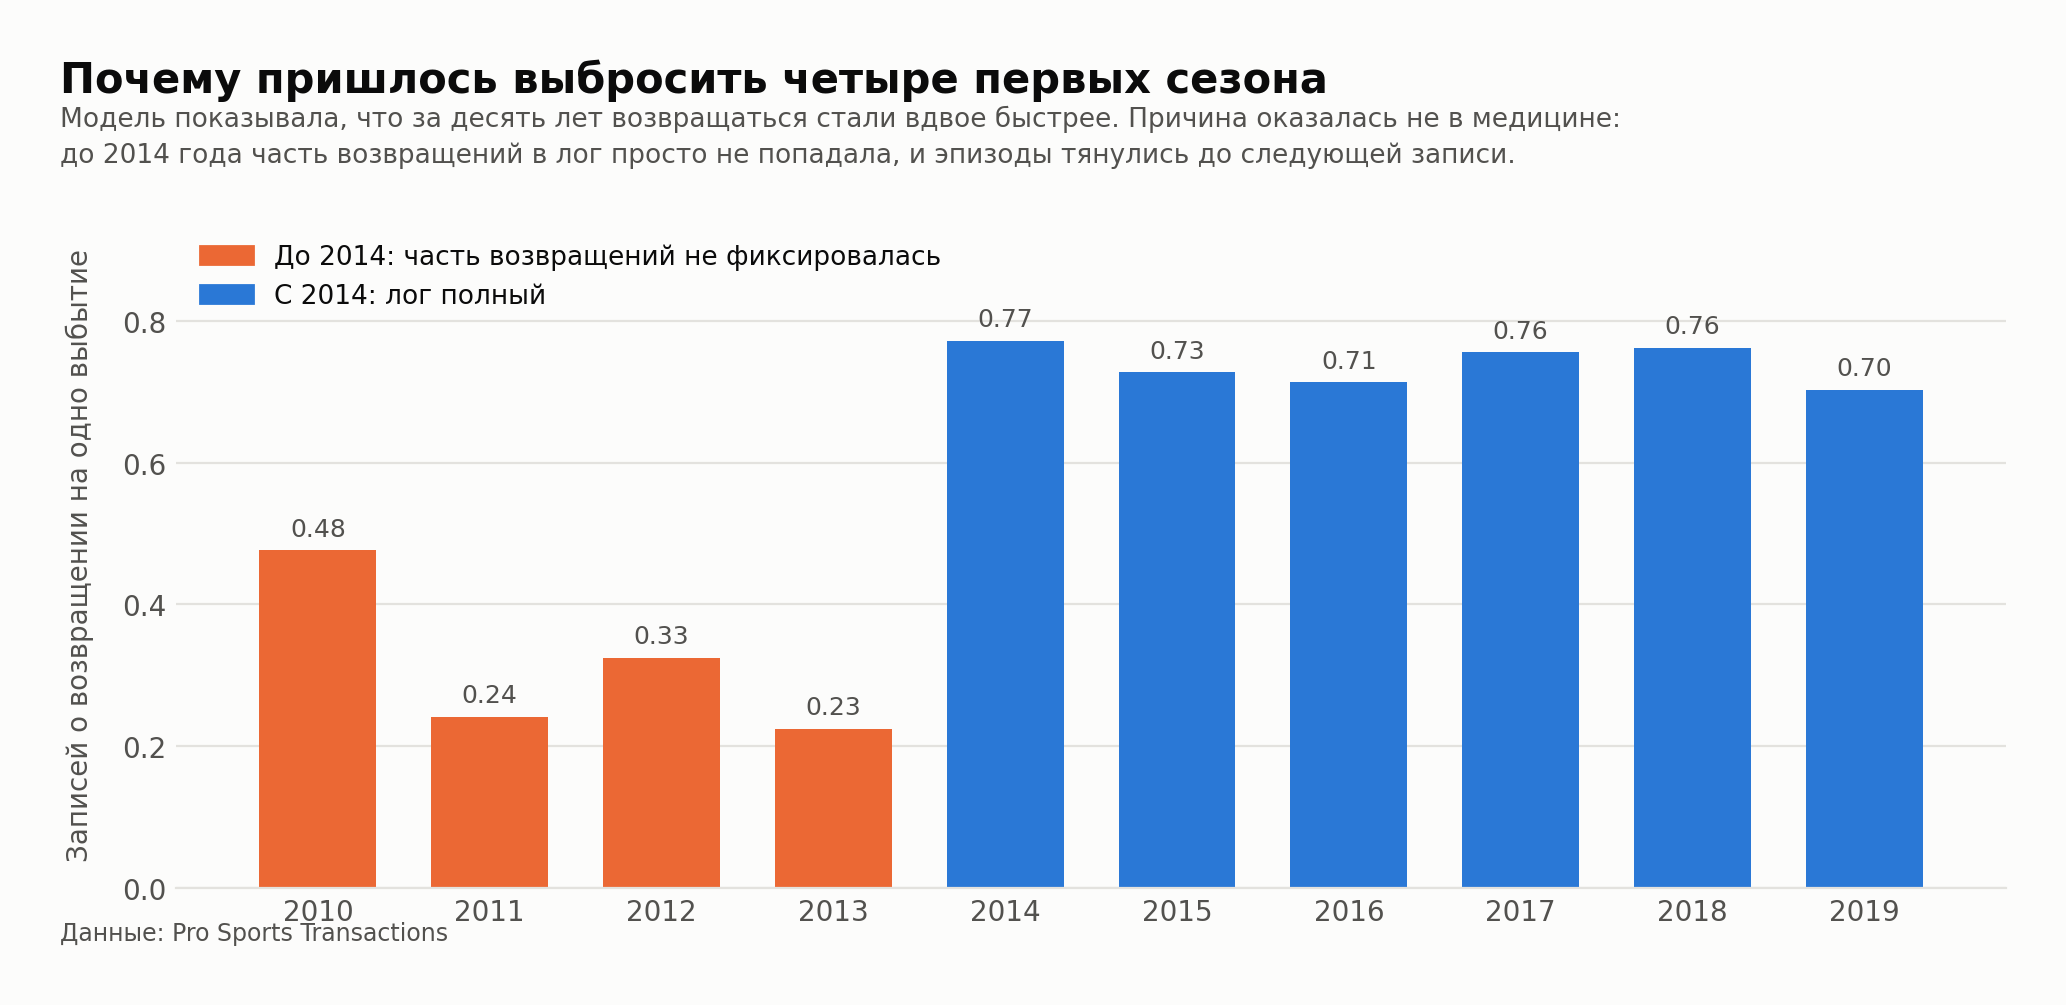

In [5]:
F.logging_artifact(
    counts["возвратов на выбытие"],
    Path("03_logging_artifact.png"),
    title="Почему пришлось выбросить четыре первых сезона",
    subtitle="Модель показывала, что за десять лет возвращаться стали вдвое быстрее. "
             "Причина оказалась не в медицине:\nдо 2014 года часть возвращений в лог "
             "просто не попадала, и эпизоды тянулись до следующей записи.",
    source="Данные: Pro Sports Transactions")

from IPython.display import Image, display
display(Image("03_logging_artifact.png", width=980))

## Когорта: сезоны 2014/15 – 2019/20

In [6]:
cohort = cohort_all[cohort_all.season >= 2014].copy()
print(f"эпизодов: {len(cohort)} | возвращений: {cohort.event.sum()} | "
      f"цензурировано: {(1 - cohort.event).sum()}")

rows = []
for inj, g in cohort.groupby("injury"):
    p90, _, _ = sv.share_returned_by(g.time.values, g.event.values, 90)
    p180, _, _ = sv.share_returned_by(g.time.values, g.event.values, 180)
    p365, lo, hi = sv.share_returned_by(g.time.values, g.event.values, 365)
    rows.append({
        "травма": inj, "n": len(g), "событий": int(g.event.sum()),
        "медиана, дней": sv.median_return_time(g.time.values, g.event.values),
        "к 90 дням": round(p90 * 100, 1),
        "к 180 дням": round(p180 * 100, 1),
        "к году": round(p365 * 100, 1),
        "интервал": f"{lo*100:.0f}-{hi*100:.0f}",
    })
pd.DataFrame(rows).sort_values("медиана, дней", ascending=False).reset_index(drop=True)

эпизодов: 239 | возвращений: 218 | цензурировано: 21


,травма,n,событий,"медиана, дней",к 90 дням,к 180 дням,к году,интервал
0,Разрыв ахиллова сухожилия,16,11,277.0,12.5,25.5,55.3,32-81
1,Разрыв ПКС (ACL),17,13,203.0,23.5,42.6,91.0,68-99
2,Разрыв мениска,21,21,96.0,42.9,81.0,95.2,80-100
3,Повреждение связок колена (MCL/PCL),29,27,50.0,55.2,89.7,93.1,80-99
4,Перелом,156,146,40.0,67.3,86.2,95.2,91-98


In [7]:
chi, p = sv.logrank(cohort)
print(f"log-rank: chi2 = {chi:.1f}, p = {p:.2e}")
print("кривые возвращения у типов повреждений различаются неслучайно")

log-rank: chi2 = 27.3, p = 1.76e-05
кривые возвращения у типов повреждений различаются неслучайно


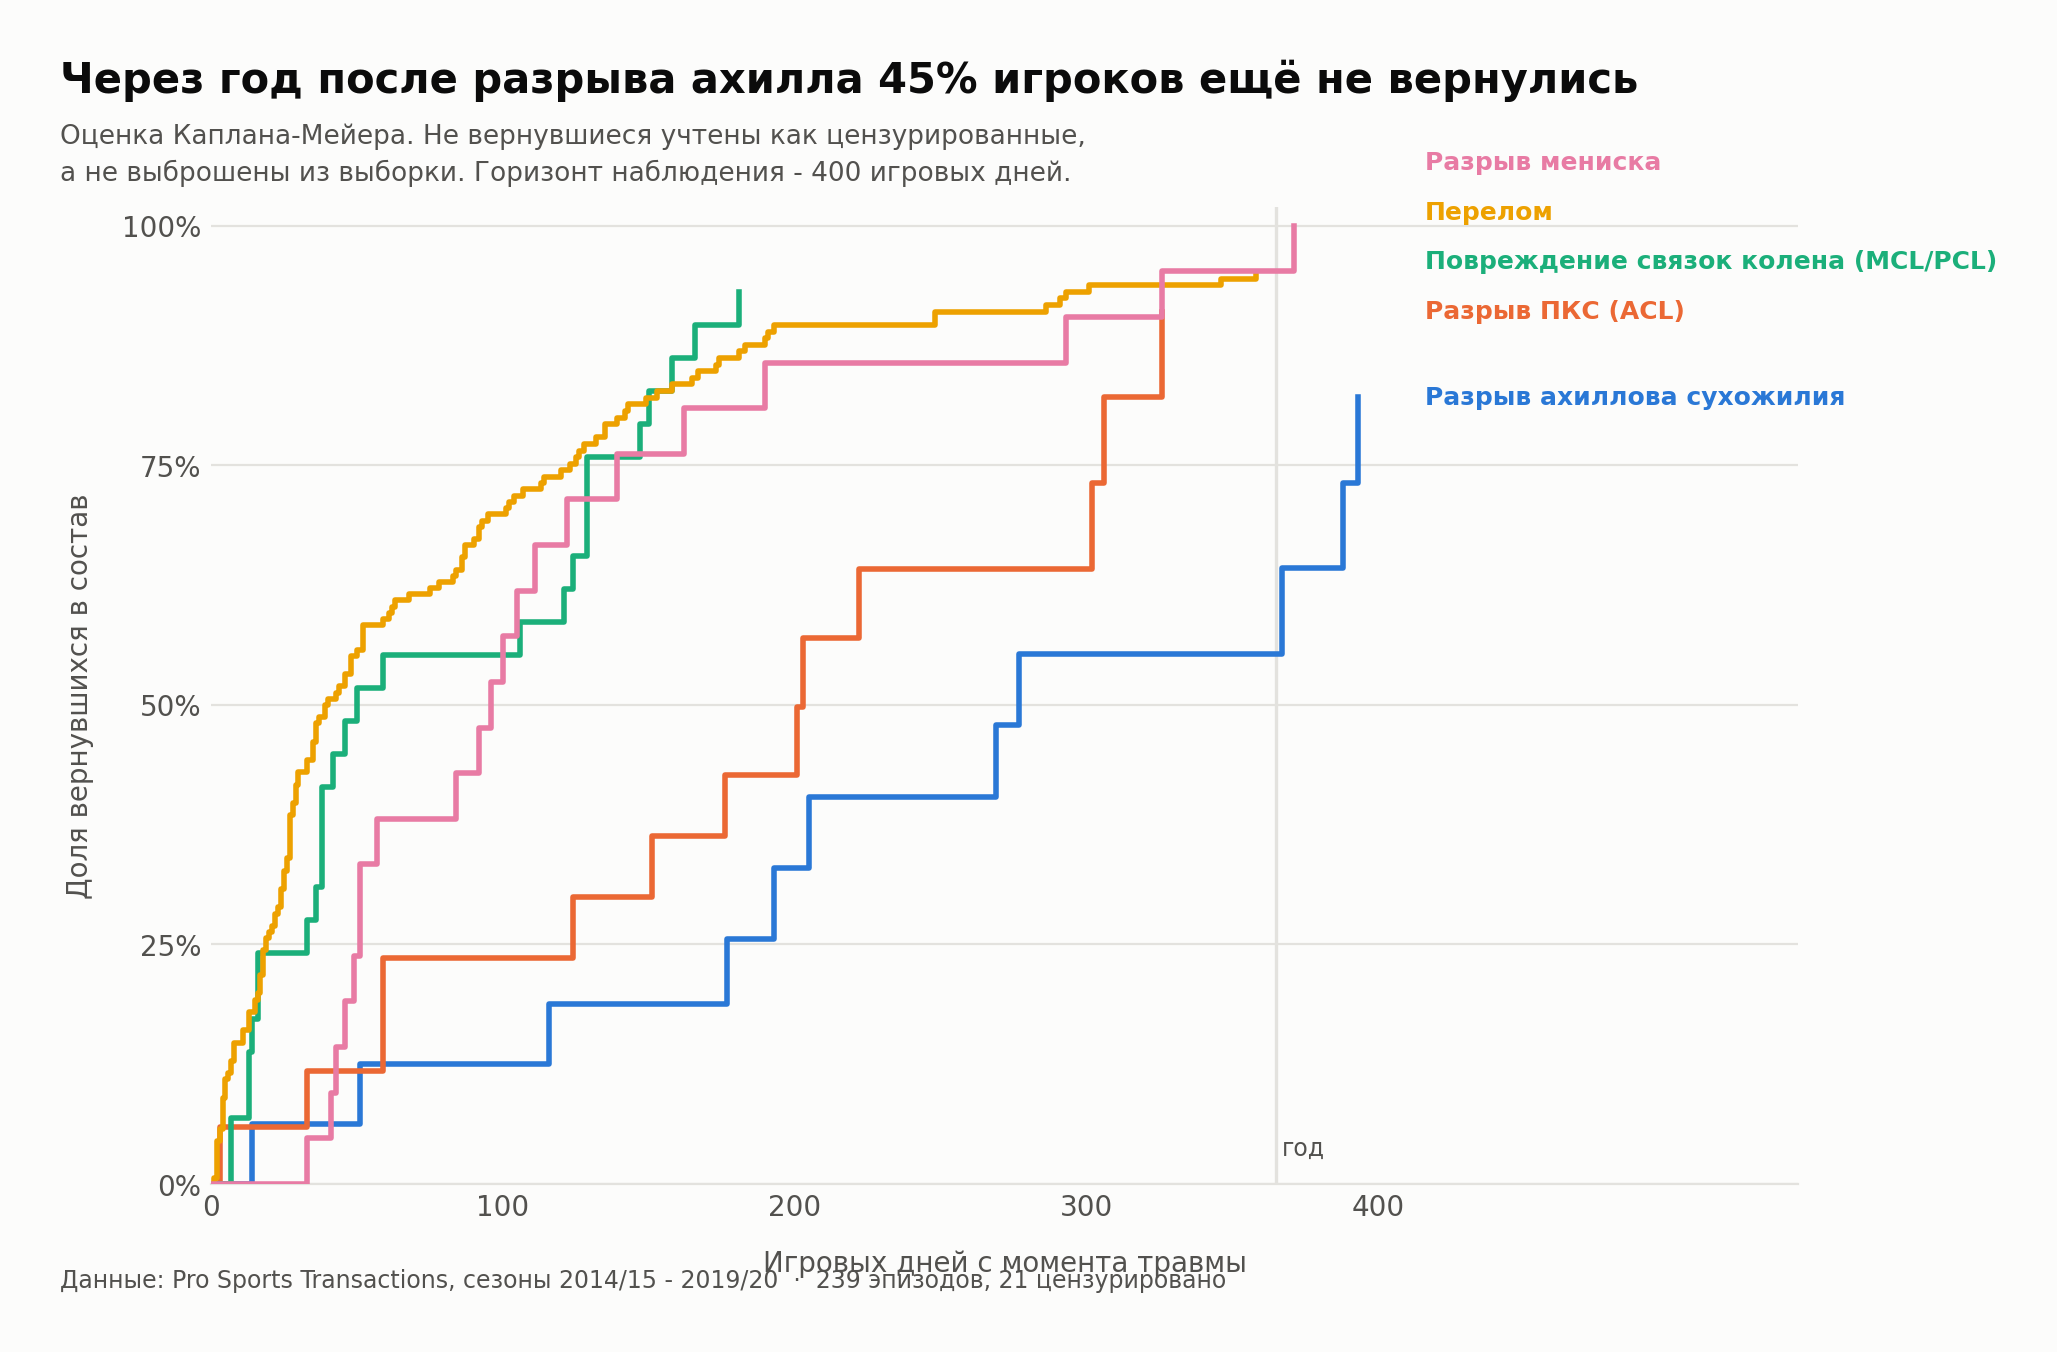

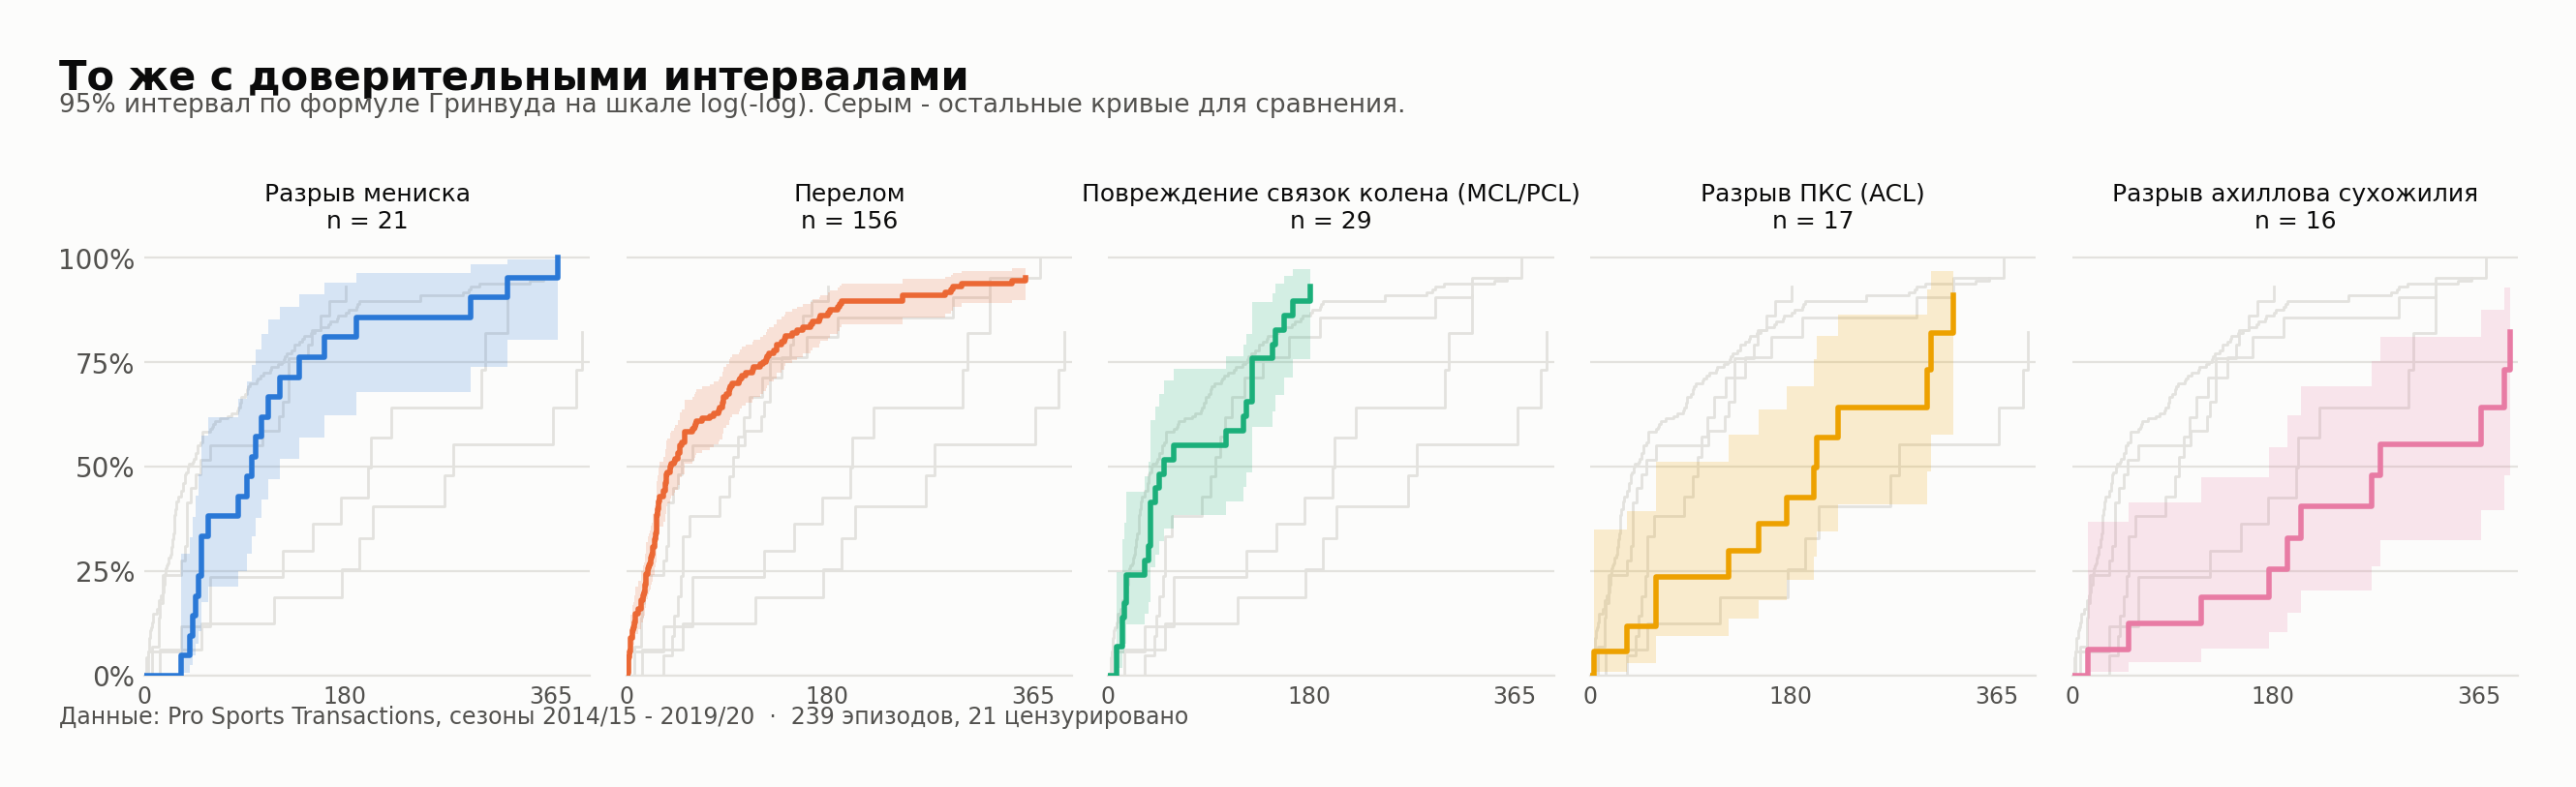

In [8]:
curves = {k: sv.km_curve(g.time.values, g.event.values) for k, g in cohort.groupby("injury")}
counts_by = {k: len(g) for k, g in cohort.groupby("injury")}
ach = cohort[cohort.injury == "Разрыв ахиллова сухожилия"]
p365, _, _ = sv.share_returned_by(ach.time.values, ach.event.values, 365)
src = (f"Данные: Pro Sports Transactions, сезоны 2014/15 - 2019/20  ·  "
       f"{len(cohort)} эпизодов, {int((1 - cohort.event).sum())} цензурировано")

F.return_curves(curves, Path("01_km_curves.png"),
    title=f"Через год после разрыва ахилла {100 - p365*100:.0f}% игроков ещё не вернулись",
    subtitle="Оценка Каплана-Мейера. Не вернувшиеся учтены как цензурированные,\n"
             "а не выброшены из выборки. Горизонт наблюдения - 400 игровых дней.",
    source=src)
F.return_curves_panels(curves, counts_by, Path("02_km_panels.png"),
    title="То же с доверительными интервалами",
    subtitle="95% интервал по формуле Гринвуда на шкале log(-log). "
             "Серым - остальные кривые для сравнения.",
    source=src)

display(Image("01_km_curves.png", width=980))
display(Image("02_km_panels.png", width=980))

## Что влияет на скорость возвращения

Регрессия Кокса. Отношение рисков выше единицы означает, что событие наступает раньше;
ниже единицы — позже. База сравнения — перелом, самая массовая группа.

In [9]:
c = cohort.dropna(subset=["age", "min_before"]).copy()
c["inj"] = pd.Categorical(c.injury, categories=[
    "Перелом", "Повреждение связок колена (MCL/PCL)", "Разрыв мениска",
    "Разрыв ПКС (ACL)", "Разрыв ахиллова сухожилия"])
c["age_c"] = c.age - c.age.mean()
c["min_c"] = c.min_before - c.min_before.mean()
c["season_c"] = c.season - 2016

model = sv.cox(c, "time ~ C(inj) + age_c + min_c + season_c")
table = sv.cox_table(model)
table.index = ["Повреждение связок колена (MCL/PCL)", "Разрыв мениска", "Разрыв ПКС (ACL)",
               "Разрыв ахиллова сухожилия", "Возраст, +1 год",
               "Минуты до травмы, +1", "Сезон, +1"]
print(f"n = {len(c)}, событий = {int(c.event.sum())}\n")
table

n = 195, событий = 179



,HR,CI_low,CI_high,p
Повреждение связок колена (MCL/PCL),0.781,0.504,1.210,0.2682
Разрыв мениска,0.584,0.338,1.008,0.0535
Разрыв ПКС (ACL),0.357,0.183,0.697,0.0026
Разрыв ахиллова сухожилия,0.217,0.114,0.411,0.0000
"Возраст, +1 год",1.032,0.987,1.079,0.1676
"Минуты до травмы, +1",1.005,0.988,1.023,0.5596
"Сезон, +1",1.045,0.947,1.153,0.3827


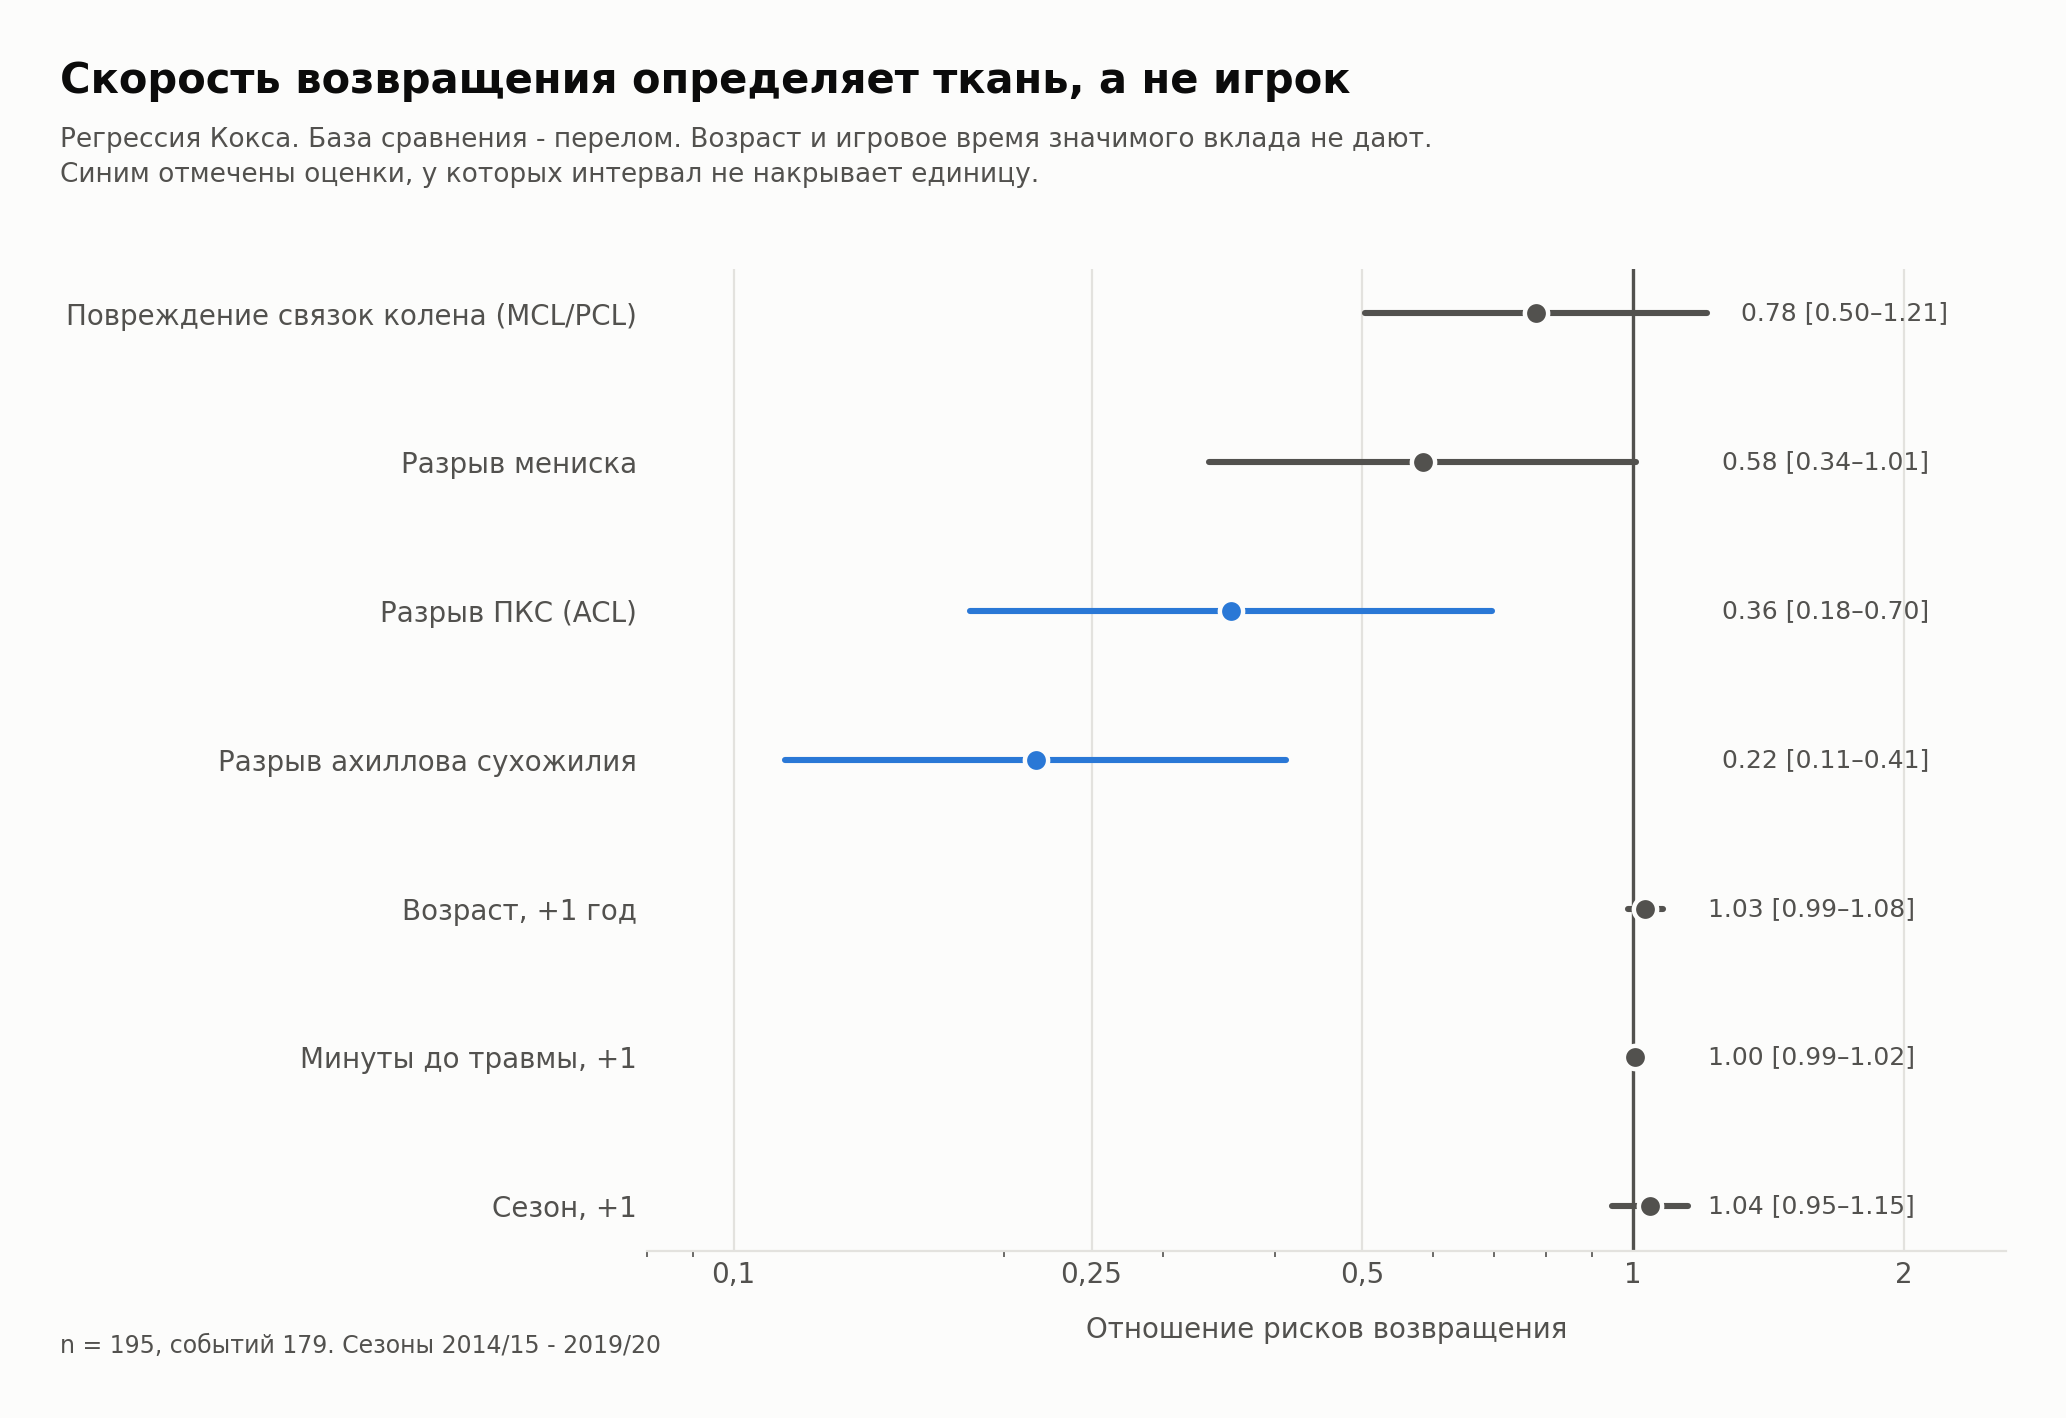

In [10]:
F.forest(table, Path("04_forest.png"),
    title="Скорость возвращения определяет ткань, а не игрок",
    subtitle="Регрессия Кокса. База сравнения - перелом. Возраст и игровое время "
             "значимого вклада не дают.\nСиним отмечены оценки, у которых интервал "
             "не накрывает единицу.",
    source=f"n = {len(c)}, событий {int(c.event.sum())}. Сезоны 2014/15 - 2019/20")
display(Image("04_forest.png", width=980))

Сезонный коэффициент на чистом окне — 1,04 с интервалом, накрывающим единицу.
Эффект, который на полной выборке выглядел мощным и значимым, исчез полностью. Это и был
тест: настоящая закономерность не пропадает от смены окна, артефакт пропадает.

## Проверка допущений

Модель Кокса предполагает, что отношение рисков постоянно во времени. Если это не так,
одно число перестаёт описывать эффект. Проверяю двумя способами.

In [11]:
ll = sv.ph_assumption_check(cohort)
from scipy import stats as st
print("наклон кривой log(-log S) по log(времени); при выполненном допущении наклоны близки\n")
for g, dd in ll.groupby("group"):
    if len(dd) < 5:
        continue
    sl, _, _, _, se = st.linregress(dd.log_time, dd.loglog_surv)
    print(f"  {g:36s} наклон = {sl:5.2f} ± {se:.2f}")

наклон кривой log(-log S) по log(времени); при выполненном допущении наклоны близки

  Перелом                              наклон =  0.81 ± 0.01
  Повреждение связок колена (MCL/PCL)  наклон =  0.96 ± 0.05
  Разрыв ПКС (ACL)                     наклон =  0.74 ± 0.10
  Разрыв ахиллова сухожилия            наклон =  0.94 ± 0.11
  Разрыв мениска                       наклон =  1.59 ± 0.13


In [12]:
print("эффект ахилла в двух окнах времени:\n")
cc = cohort.dropna(subset=["age", "min_before"]).copy()
cc["ach"] = (cc.injury == "Разрыв ахиллова сухожилия").astype(float)
for cut, lbl in [(180, "события в первые 180 дней"), (400, "все события до 400 дней")]:
    w = pd.DataFrame({
        "time": np.clip(cc.time.values, None, cut),
        "event": ((cc.time.values <= cut) & (cc.event.values == 1)).astype(int),
        "ach": cc.ach.values, "age": 0.0, "min_before": 0.0,
    })
    r = sv.cox_table(sv.cox(w, "time ~ ach")).loc["ach"]
    print(f"  {lbl:28s} HR = {r.HR:.2f} [{r.CI_low:.2f}-{r.CI_high:.2f}]")

эффект ахилла в двух окнах времени:

  события в первые 180 дней    HR = 0.15 [0.05-0.39]
  все события до 400 дней      HR = 0.30 [0.16-0.56]


Мениск выбивается по наклону, и эффект ахилла в первые полгода заметно сильнее, чем
в среднем по горизонту. Допущение пропорциональности выполняется приблизительно, а не
строго. Практический вывод: отношения рисков из таблицы нужно читать как усреднённые по
окну наблюдения, а не как постоянную величину. Кривые Каплана–Мейера от этого не страдают,
они никаких допущений о форме не делают.

## Насколько устойчива главная цифра

In [13]:
ach = cohort[cohort.injury == "Разрыв ахиллова сухожилия"]
point, lo, hi = sv.share_returned_by(ach.time.values, ach.event.values, 365)

rng = np.random.default_rng(7)
boot = []
for _ in range(2000):
    g = ach.iloc[rng.integers(0, len(ach), len(ach))]
    b, _, _ = sv.share_returned_by(g.time.values, g.event.values, 365)
    boot.append(b)
boot = np.array(boot)

print(f"вернулись к году после разрыва ахилла, n = {len(ach)}\n")
print(f"  Каплан-Мейер:  {point*100:.1f}%   интервал по Гринвуду [{lo*100:.0f}-{hi*100:.0f}]")
print(f"  бутстрэп 2000: {boot.mean()*100:.1f}%   интервал [{np.percentile(boot, 2.5)*100:.0f}-"
      f"{np.percentile(boot, 97.5)*100:.0f}]")

вернулись к году после разрыва ахилла, n = 16

  Каплан-Мейер:  55.3%   интервал по Гринвуду [32-81]
  бутстрэп 2000: 55.7%   интервал [28-81]


Два независимых способа оценить неопределённость дают один ответ. Интервал широкий —
шестнадцать эпизодов это шестнадцать эпизодов, — но точечная оценка устойчива.

## Выводы

Тип повреждённой ткани определяет срок возвращения, а характеристики игрока — нет.
Возраст и игровое время до травмы значимого вклада не дают, тогда как разрыв ахиллова
сухожилия возвращает игрока в состав в четыре с половиной раза медленнее перелома
(HR 0,22 при интервале от 0,11 до 0,41).

Разрыв ахилла стоит особняком даже среди тяжёлых травм. Медиана возвращения — 277 игровых
дней, и через год после травмы почти половина игроков ещё не вышла на площадку. У ПКС при
сопоставимой медиане 203 дня к году возвращаются девять из десяти. Разница не в сроке,
а в доле тех, кто не возвращается вовсе.

Улучшения сроков за десятилетие в данных нет. Эффект, который выглядел как двукратное
ускорение восстановления, полностью объяснился тем, что журнал транзакций стал полнее
с 2014 года.

## Чего эта работа не говорит

Возвращение в состав — не восстановление. Данные фиксируют день, когда игрок снова стал
доступен тренеру, а не день, когда он снова стал собой. Это разные события, и второе
требует игровой статистики до и после.

Тяжесть определяется по свободному тексту. В категории повреждений связок колена признак
разрыва нашёлся лишь у четырёх эпизодов из сорока пяти, остальное — растяжения, поэтому
категория названа повреждением. У ахилла, мениска и ПКС разметка чистая.

Выборки малы там, где интереснее всего. Шестнадцать разрывов ахилла и семнадцать ПКС
дают порядок величины, но не точное число, что видно по ширине интервалов.

Горизонт в 400 игровых дней выбран из соображений здравого смысла, а не выведен из данных.
Игроки, вернувшиеся позже, засчитаны как невернувшиеся.

Допущение пропорциональных рисков выполняется приблизительно, поэтому отношения рисков —
усреднённые по окну величины.

---

Данные: [Pro Sports Transactions](https://www.prosportstransactions.com/) через
[gboogy/nba-injury-data-scraper](https://github.com/gboogy/nba-injury-data-scraper);
статистика игроков — [Brescou/NBA-dataset-stats-player-team](https://github.com/Brescou/NBA-dataset-stats-player-team).